# 05 — Qual Modelo Escolher

Eu não quis usar um modelo só porque é popular. Testei oito algoritmos diferentes, do mais
simples (regressão linear) aos mais sofisticados (XGBoost, LightGBM), todos com a mesma
validação por viveiro, pra ver qual se sai melhor com os meus dados.

In [1]:
import sys, os
sys.path.insert(0, os.path.abspath(".."))
import warnings; warnings.filterwarnings("ignore")
import numpy as np, pandas as pd, matplotlib.pyplot as plt
plt.rcParams['figure.dpi']=100; plt.rcParams['axes.grid']=True; plt.rcParams['grid.alpha']=0.3

In [2]:
from src.modelo_peso import comparar
tab, n, nv = comparar()
print(f"{n} biometrias | {nv} viveiros")
tab.round(3)

2072 biometrias | 20 viveiros


,Modelo,MAE,RMSE,R2
0,Extra Trees,2.371,3.535,0.703
1,Random Forest,2.406,3.630,0.682
2,HistGradientBoosting,2.455,3.681,0.673
3,XGBoost,2.487,3.766,0.659
4,LightGBM,2.514,3.786,0.654
5,SVR,2.588,3.805,0.660
6,Gradient Boosting,2.535,3.880,0.627
7,Ridge (linear),3.145,4.800,0.382
8,Baseline (média),5.186,6.531,-0.005


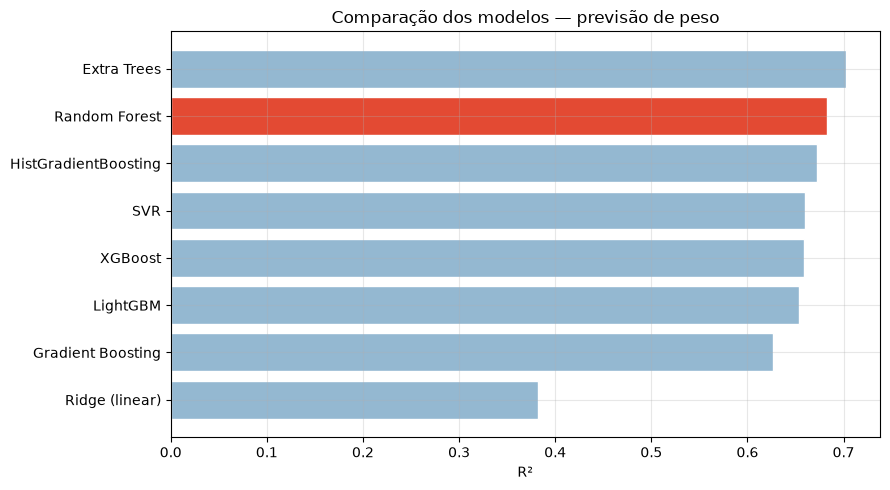

In [3]:
fig, ax = plt.subplots(figsize=(9,5))
t = tab[tab["Modelo"]!="Baseline (média)"].sort_values("R2")
cores = ["#e34a33" if m=="Random Forest" else "#94b8d1" for m in t["Modelo"]]
ax.barh(t["Modelo"], t["R2"], color=cores, edgecolor="white")
ax.set_xlabel("R²"); ax.set_title("Comparação dos modelos — previsão de peso")
plt.tight_layout(); plt.show()

Os modelos de árvore (Random Forest, Extra Trees, os boostings) ficaram todos parecidos
e bem à frente da regressão linear e do baseline. Escolhi o **Random Forest** porque tem
um dos melhores desempenhos, é robusto e fácil de interpretar que é o que eu preciso pro
próximo passo. A diferença pro Extra Trees é mínima, dentro da margem de variação.

**Próximo (06):** o que mais influencia o peso.